In [1]:
import sys
from pathlib import Path

# Add project root to path
project_root = Path().absolute().parent
sys.path.append(str(project_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
import joblib

# TensorFlow and Keras
import tensorflow as tf
from tensorflow import keras

# Metrics
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

# Project imports
from config.config import Config
from src.data_loader import StockDataLoader

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print("✓ Imports successful")

✓ Imports successful


In [19]:
# Load configuration
config = Config()

# Load model
model_dir = project_root / 'models' / 'saved_models'
model_files = list(model_dir.glob('*.keras'))

if model_files:
    model_path = sorted(model_files)[-1]
    print(f"Loading model: {model_path.name}")
    model = keras.models.load_model(model_path)
    print(" Model loaded")
else:
    print(" No models found!")

# Load scalers
scaler_dir = project_root / 'models' / 'scalers'
feature_scaler = joblib.load(scaler_dir / 'feature_scaler.pkl')
target_scaler = joblib.load(scaler_dir / 'target_scaler.pkl')
print(" Scalers loaded")

# Load data
data_path = project_root / config.data.raw_data_path
data_loader = StockDataLoader(str(data_path))
df = data_loader.load_csv(date_column=config.data.date_column)
df[config.data.date_column] = pd.to_datetime(df[config.data.date_column])

print(f" Loaded {len(df):,} records")
print(f" Date range: {df[config.data.date_column].min()} to {df[config.data.date_column].max()}")

INFO:src.data_loader:Loaded 245 records from c:\Users\USER\OneDrive\Documents\GitHub\Research-Project\backend\lstm_stock_prediction\data\processed\lstm_ready_data.csv


Loading model: lstm_model_20260301_113127.keras
 Model loaded
 Scalers loaded
 Loaded 245 records
 Date range: 2000-01-01 00:00:00 to 2020-06-01 00:00:00


## 3. Prepare Data Functions

In [20]:
def prepare_data(df, feature_cols, target_col, sequence_length):
    """
    Prepare data for model prediction.
    """
    features = df[feature_cols].values
    target = df[target_col].values.reshape(-1, 1)
    
    # Scale
    scaled_features = feature_scaler.transform(features)
    scaled_target = target_scaler.transform(target)
    
    # Create sequences
    X, y = [], []
    for i in range(sequence_length, len(scaled_features)):
        X.append(scaled_features[i-sequence_length:i])
        y.append(scaled_target[i])
    
    return np.array(X), np.array(y)

def calculate_metrics(y_true, y_pred):
    """
    Calculate evaluation metrics.
    """
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2 = r2_score(y_true, y_pred)
    
    return {'RMSE': rmse, 'MAE': mae, 'MAPE': mape, 'R2': r2}

print(" Helper functions defined")

 Helper functions defined


##  Time-Based Validation

In [21]:
# Split data by time periods
df_sorted = df.sort_values(config.data.date_column)
total_records = len(df_sorted)

# Define time splits (4 equal quarters)
quarter_size = total_records // 4

time_periods = [
    ('Q1 (Earliest)', 0, quarter_size),
    ('Q2', quarter_size, 2*quarter_size),
    ('Q3', 2*quarter_size, 3*quarter_size),
    ('Q4 (Latest)', 3*quarter_size, total_records)
]

print("=" * 70)
print("TIME-BASED VALIDATION")
print("=" * 70)

time_metrics = []

for period_name, start_idx, end_idx in time_periods:
    df_period = df_sorted.iloc[start_idx:end_idx].copy()
    
    if len(df_period) > config.preprocessing.sequence_length:
        X, y = prepare_data(
            df_period,
            config.data.feature_columns,
            config.data.target_column,
            config.preprocessing.sequence_length
        )
        
        # Make predictions
        y_pred = model.predict(X, verbose=0)
        
        # Inverse transform
        y_actual = target_scaler.inverse_transform(y)
        y_pred_actual = target_scaler.inverse_transform(y_pred)
        
        # Calculate metrics
        metrics = calculate_metrics(y_actual, y_pred_actual)
        
        date_range = f"{df_period[config.data.date_column].min().strftime('%Y-%m-%d')} to {df_period[config.data.date_column].max().strftime('%Y-%m-%d')}"
        
        time_metrics.append({
            'Period': period_name,
            'Date Range': date_range,
            'Samples': len(X),
            **metrics
        })
        
        print(f"\n{period_name}:")
        print(f"  Date Range: {date_range}")
        print(f"  Samples: {len(X):,}")
        print(f"  RMSE: {metrics['RMSE']:.4f}")
        print(f"  MAE: {metrics['MAE']:.4f}")
        print(f"  MAPE: {metrics['MAPE']:.2f}%")
        print(f"  R²: {metrics['R2']:.4f}")

time_metrics_df = pd.DataFrame(time_metrics)

print(time_metrics_df.to_string(index=False))

TIME-BASED VALIDATION

Q1 (Earliest):
  Date Range: 2000-01-01 to 2005-01-01
  Samples: 49
  RMSE: 98.4327
  MAE: 88.3356
  MAPE: 124.89%
  R²: 0.0604

Q2:
  Date Range: 2005-02-01 to 2010-02-01
  Samples: 49
  RMSE: 168.7212
  MAE: 123.9292
  MAPE: 39.98%
  R²: 0.1657

Q3:
  Date Range: 2010-03-01 to 2015-03-01
  Samples: 49
  RMSE: 319.7285
  MAE: 251.2202
  MAPE: 45.22%
  R²: 0.3904

Q4 (Latest):
  Date Range: 2015-04-01 to 2020-06-01
  Samples: 50
  RMSE: 119.2217
  MAE: 90.1484
  MAPE: 28.85%
  R²: 0.0635
       Period               Date Range  Samples       RMSE        MAE       MAPE       R2
Q1 (Earliest) 2000-01-01 to 2005-01-01       49  98.432680  88.335631 124.889047 0.060356
           Q2 2005-02-01 to 2010-02-01       49 168.721218 123.929199  39.980157 0.165700
           Q3 2010-03-01 to 2015-03-01       49 319.728460 251.220152  45.217157 0.390368
  Q4 (Latest) 2015-04-01 to 2020-06-01       50 119.221728  90.148393  28.849751 0.063521


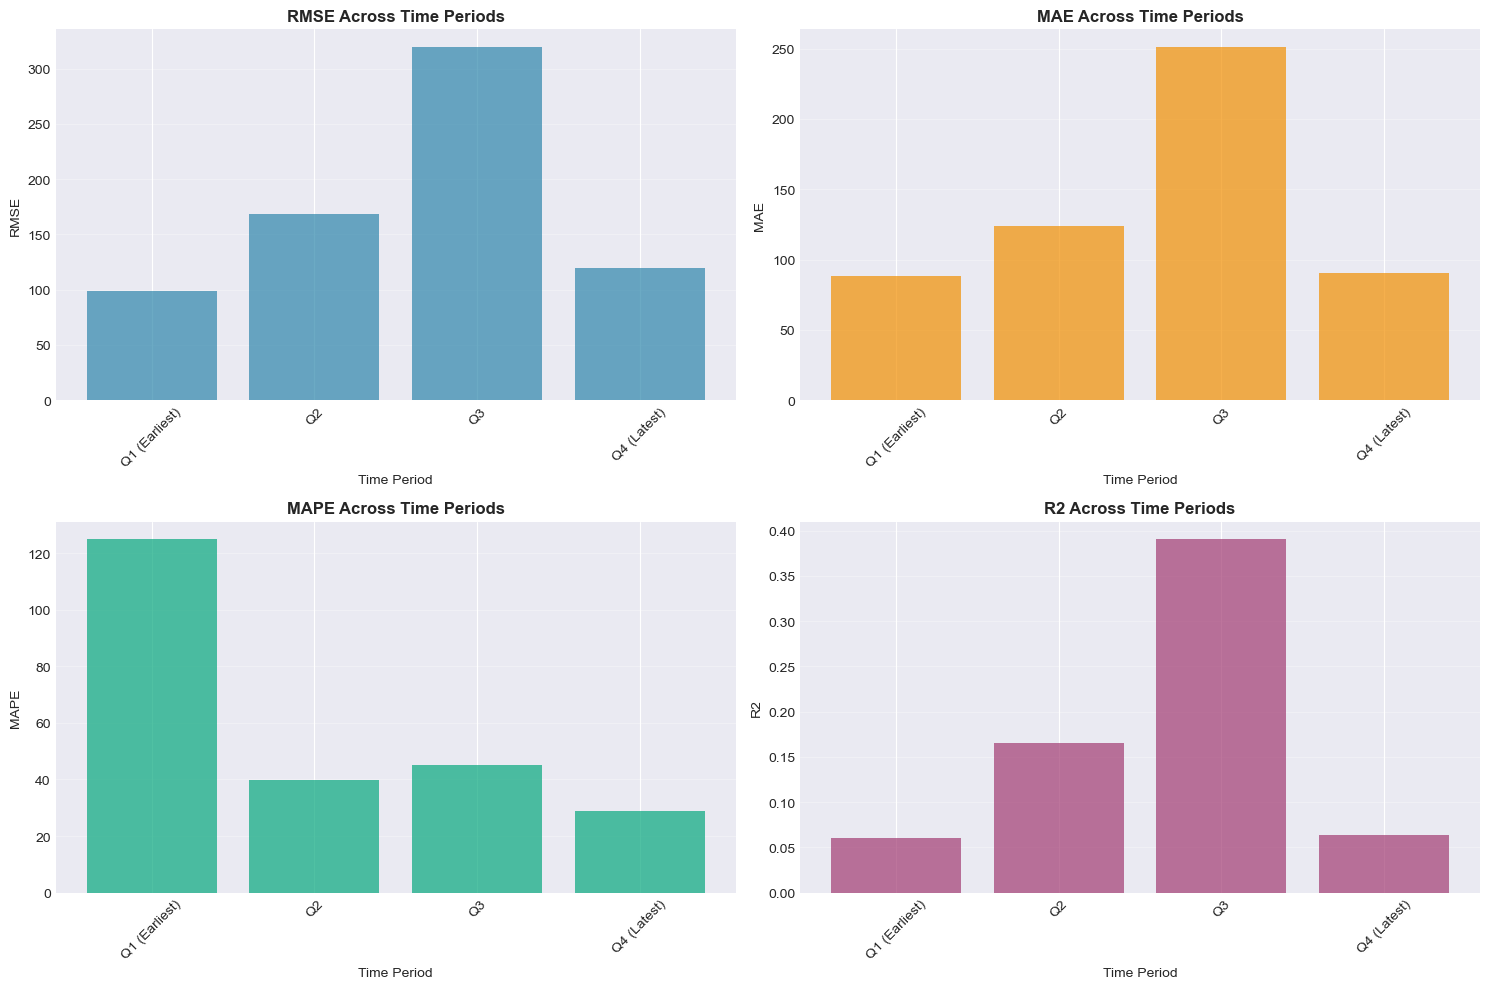

In [5]:
# Visualize time-based performance
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

metrics_to_plot = ['RMSE', 'MAE', 'MAPE', 'R2']
colors = ['#2E86AB', '#F18F01', '#06A77D', '#A23B72']

for idx, (metric, color) in enumerate(zip(metrics_to_plot, colors)):
    ax = axes[idx // 2, idx % 2]
    ax.bar(time_metrics_df['Period'], time_metrics_df[metric], color=color, alpha=0.7)
    ax.set_title(f'{metric} Across Time Periods', fontsize=12, fontweight='bold')
    ax.set_xlabel('Time Period')
    ax.set_ylabel(metric)
    ax.grid(True, alpha=0.3, axis='y')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 5. Walk-Forward Validation

In [14]:
# Walk-forward validation

print("WALK-FORWARD VALIDATION")


# Use sliding windows of fixed size
window_size = len(df_sorted) // 5  # 5 windows
step_size = window_size // 2  # 50% overlap

walk_forward_results = []
window_num = 1

for start_idx in range(0, len(df_sorted) - window_size, step_size):
    end_idx = start_idx + window_size
    df_window = df_sorted.iloc[start_idx:end_idx].copy()
    
    if len(df_window) > config.preprocessing.sequence_length:
        X, y = prepare_data(
            df_window,
            config.data.feature_columns,
            config.data.target_column,
            config.preprocessing.sequence_length
        )
        
        # Predict
        y_pred = model.predict(X, verbose=0)
        
        # Inverse transform
        y_actual = target_scaler.inverse_transform(y)
        y_pred_actual = target_scaler.inverse_transform(y_pred)
        
        # Calculate metrics
        metrics = calculate_metrics(y_actual, y_pred_actual)
        
        date_start = df_window[config.data.date_column].min().strftime('%Y-%m-%d')
        date_end = df_window[config.data.date_column].max().strftime('%Y-%m-%d')
        
        walk_forward_results.append({
            'Window': f'W{window_num}',
            'Date Range': f"{date_start} to {date_end}",
            'Samples': len(X),
            **metrics
        })
        
        print(f"\nWindow {window_num}: {date_start} to {date_end}")
        print(f"  RMSE: {metrics['RMSE']:.4f} | MAE: {metrics['MAE']:.4f} | MAPE: {metrics['MAPE']:.2f}% | R²: {metrics['R2']:.4f}")
        
        window_num += 1

walk_forward_df = pd.DataFrame(walk_forward_results)
print("\n" + "=" * 70)
print(walk_forward_df.to_string(index=False))

WALK-FORWARD VALIDATION

Window 1: 2000-01-01 to 2004-01-01
  RMSE: 101.3597 | MAE: 91.9969 | MAPE: 152.36% | R²: -0.2242

Window 2: 2002-01-01 to 2006-01-01
  RMSE: 113.5066 | MAE: 97.2269 | MAPE: 51.69% | R²: 0.2592

Window 3: 2004-01-01 to 2008-01-01
  RMSE: 117.9051 | MAE: 95.8344 | MAPE: 34.33% | R²: -0.1986

Window 4: 2006-01-01 to 2010-01-01
  RMSE: 172.7909 | MAE: 131.8260 | MAPE: 45.01% | R²: 0.0900

Window 5: 2008-01-01 to 2012-01-01
  RMSE: 473.9576 | MAE: 365.4239 | MAPE: 38.76% | R²: 0.2210

Window 6: 2010-01-01 to 2014-01-01
  RMSE: 407.5766 | MAE: 309.7269 | MAPE: 49.50% | R²: 0.4279

Window 7: 2012-01-01 to 2016-01-01
  RMSE: 180.5850 | MAE: 139.9439 | MAPE: 31.40% | R²: -0.1405

Window 8: 2014-01-01 to 2018-01-01
  RMSE: 100.8753 | MAE: 86.4642 | MAPE: 30.56% | R²: 0.1697

Window 9: 2016-01-01 to 2020-01-01
  RMSE: 114.4535 | MAE: 84.6879 | MAPE: 27.84% | R²: -0.0405

Window               Date Range  Samples       RMSE        MAE       MAPE        R2
    W1 2000-01-01 

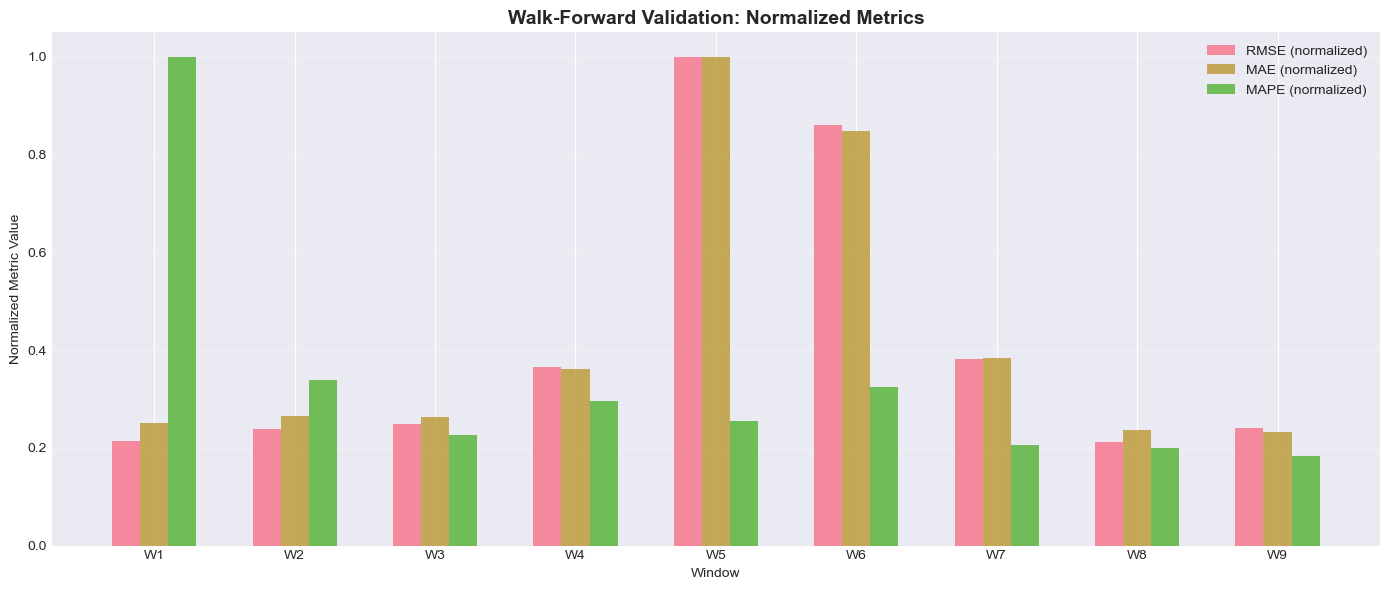

In [7]:
# Plot walk-forward results
fig, ax = plt.subplots(figsize=(14, 6))

x_pos = range(len(walk_forward_df))
width = 0.2

# Normalize metrics for comparison
rmse_norm = walk_forward_df['RMSE'] / walk_forward_df['RMSE'].max()
mae_norm = walk_forward_df['MAE'] / walk_forward_df['MAE'].max()
mape_norm = walk_forward_df['MAPE'] / walk_forward_df['MAPE'].max()

ax.bar([x - width for x in x_pos], rmse_norm, width, label='RMSE (normalized)', alpha=0.8)
ax.bar(x_pos, mae_norm, width, label='MAE (normalized)', alpha=0.8)
ax.bar([x + width for x in x_pos], mape_norm, width, label='MAPE (normalized)', alpha=0.8)

ax.set_xlabel('Window')
ax.set_ylabel('Normalized Metric Value')
ax.set_title('Walk-Forward Validation: Normalized Metrics', fontsize=14, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(walk_forward_df['Window'])
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 6. Multi-Step Ahead Prediction

In [15]:
# Test model on different prediction horizons
print("\n" + "=" * 70)
print("MULTI-STEP AHEAD PREDICTION ANALYSIS")
print("=" * 70)

# Use last portion of data for multi-step prediction
test_start_idx = int(len(df_sorted) * 0.8)
df_test = df_sorted.iloc[test_start_idx:].copy()

# Prepare data
X_test, y_test = prepare_data(
    df_test,
    config.data.feature_columns,
    config.data.target_column,
    config.preprocessing.sequence_length
)

# Test different step-ahead predictions
horizon_results = []

for steps_ahead in [1, 3, 5, 10]:
    if steps_ahead >= len(X_test):
        continue
    
    # Take every nth sample to simulate n-step ahead predictions
    y_true_horizon = y_test[::steps_ahead]
    X_horizon = X_test[::steps_ahead]
    
    # Predict
    y_pred_horizon = model.predict(X_horizon, verbose=0)
    
    # Inverse transform
    y_true_actual = target_scaler.inverse_transform(y_true_horizon)
    y_pred_actual = target_scaler.inverse_transform(y_pred_horizon)
    
    # Calculate metrics
    metrics = calculate_metrics(y_true_actual, y_pred_actual)
    
    horizon_results.append({
        'Steps Ahead': steps_ahead,
        'Samples': len(X_horizon),
        **metrics
    })
    
    print(f"\n{steps_ahead}-Step Ahead:")
    print(f"  Samples: {len(X_horizon):,}")
    print(f"  RMSE: {metrics['RMSE']:.4f}")
    print(f"  MAE: {metrics['MAE']:.4f}")
    print(f"  MAPE: {metrics['MAPE']:.2f}%")
    print(f"  R²: {metrics['R2']:.4f}")

horizon_df = pd.DataFrame(horizon_results)

print(horizon_df.to_string(index=False))


MULTI-STEP AHEAD PREDICTION ANALYSIS

1-Step Ahead:
  Samples: 37
  RMSE: 127.4841
  MAE: 93.6209
  MAPE: 27.04%
  R²: 0.0454

3-Step Ahead:
  Samples: 13
  RMSE: 151.1664
  MAE: 103.1051
  MAPE: 24.42%
  R²: 0.0710

5-Step Ahead:
  Samples: 8
  RMSE: 152.0556
  MAE: 118.5734
  MAPE: 28.85%
  R²: -0.1778

10-Step Ahead:
  Samples: 4
  RMSE: 181.7400
  MAE: 136.0965
  MAPE: 28.63%
  R²: -0.7395
 Steps Ahead  Samples       RMSE        MAE      MAPE        R2
           1       37 127.484081  93.620893 27.036719  0.045367
           3       13 151.166378 103.105138 24.424685  0.071044
           5        8 152.055552 118.573404 28.846475 -0.177812
          10        4 181.739986 136.096457 28.629191 -0.739536


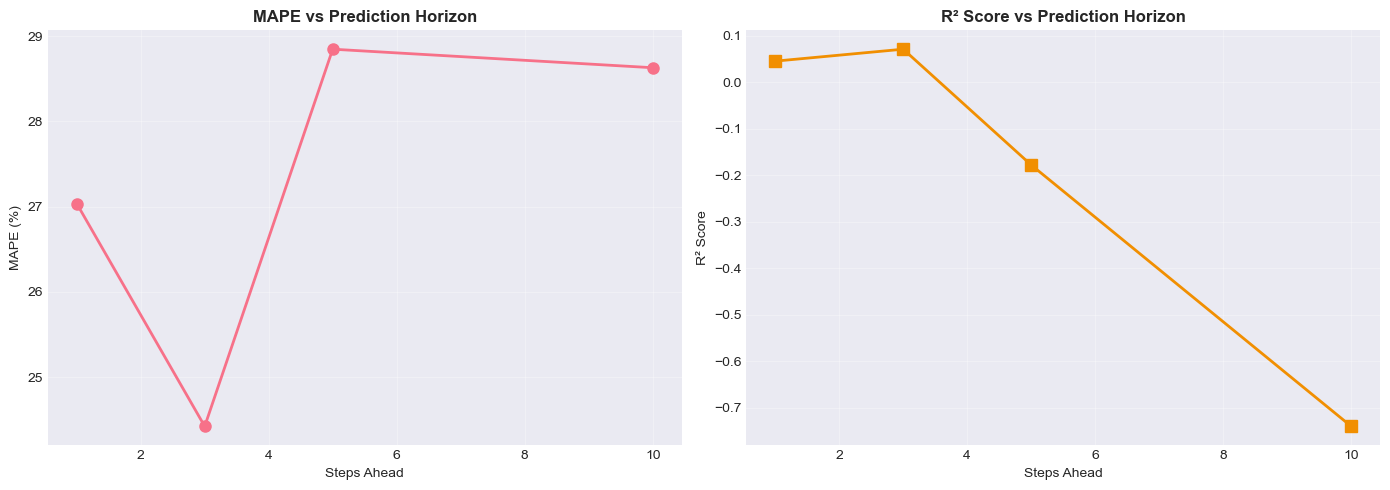

In [9]:
# Plot prediction horizon analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# MAPE vs horizon
axes[0].plot(horizon_df['Steps Ahead'], horizon_df['MAPE'], marker='o', linewidth=2, markersize=8)
axes[0].set_title('MAPE vs Prediction Horizon', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Steps Ahead')
axes[0].set_ylabel('MAPE (%)')
axes[0].grid(True, alpha=0.3)

# R² vs horizon
axes[1].plot(horizon_df['Steps Ahead'], horizon_df['R2'], marker='s', linewidth=2, markersize=8, color='#F18F01')
axes[1].set_title('R² Score vs Prediction Horizon', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Steps Ahead')
axes[1].set_ylabel('R² Score')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Model Stability Analysis

In [16]:
# Analyze prediction stability

print("MODEL STABILITY ANALYSIS")


# Make multiple predictions on the same test set
num_runs = 5
predictions_list = []

print(f"\nRunning {num_runs} prediction passes on test set...")

for run in range(num_runs):
    y_pred = model.predict(X_test[:100], verbose=0)  # Use first 100 samples
    y_pred_actual = target_scaler.inverse_transform(y_pred)
    predictions_list.append(y_pred_actual)

predictions_array = np.array(predictions_list)

# Calculate prediction variance
pred_mean = predictions_array.mean(axis=0)
pred_std = predictions_array.std(axis=0)
pred_cv = (pred_std / pred_mean) * 100  # Coefficient of variation

print(f"\nPrediction Stability Metrics:")
print(f"  Mean Std Dev: {pred_std.mean():.6f}")
print(f"  Max Std Dev: {pred_std.max():.6f}")
print(f"  Mean CV: {pred_cv.mean():.4f}%")
print(f"  Max CV: {pred_cv.max():.4f}%")

if pred_std.mean() < 0.01:
    print("\n✓ Model predictions are highly stable")
elif pred_std.mean() < 0.1:
    print("\n✓ Model predictions are reasonably stable")
else:
    print("\n⚠ Model predictions show instability")

MODEL STABILITY ANALYSIS

Running 5 prediction passes on test set...

Prediction Stability Metrics:
  Mean Std Dev: 0.000002
  Max Std Dev: 0.000015
  Mean CV: 0.0000%
  Max CV: 0.0000%

✓ Model predictions are highly stable


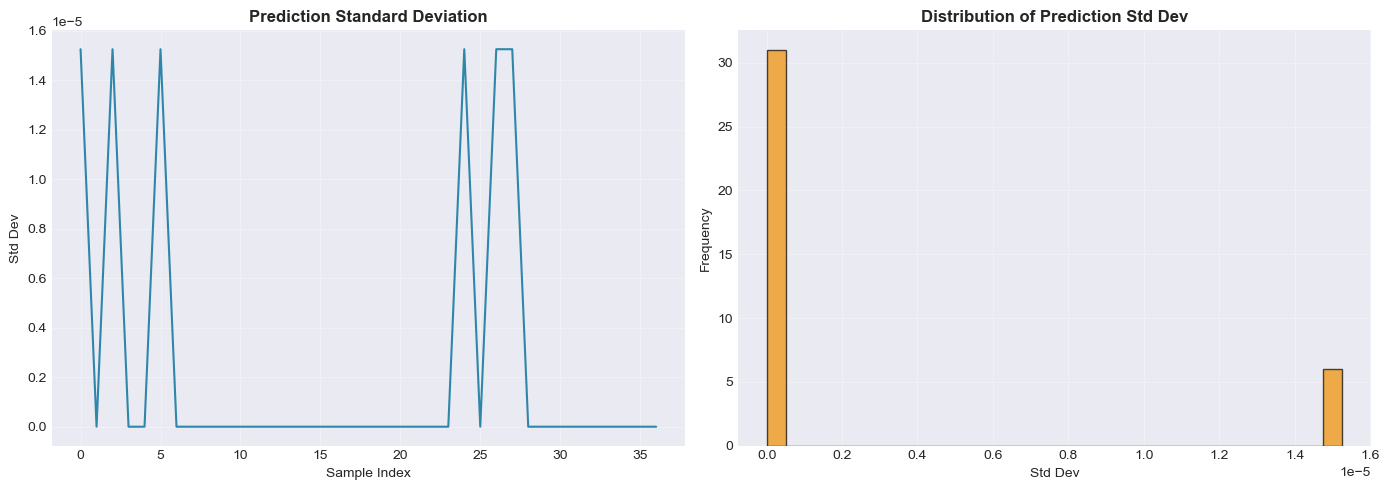

In [11]:
# Plot prediction stability
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Prediction variance over samples
axes[0].plot(pred_std.flatten(), linewidth=1.5, color='#2E86AB')
axes[0].set_title('Prediction Standard Deviation', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Sample Index')
axes[0].set_ylabel('Std Dev')
axes[0].grid(True, alpha=0.3)

# Distribution of prediction std
axes[1].hist(pred_std.flatten(), bins=30, color='#F18F01', alpha=0.7, edgecolor='black')
axes[1].set_title('Distribution of Prediction Std Dev', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Std Dev')
axes[1].set_ylabel('Frequency')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Save Validation Results

In [12]:
# Create validation results directory
validation_dir = project_root / 'results' / f'validation_{datetime.now().strftime("%Y%m%d_%H%M%S")}'
validation_dir.mkdir(parents=True, exist_ok=True)

# Save results
time_metrics_df.to_csv(validation_dir / 'time_based_validation.csv', index=False)
walk_forward_df.to_csv(validation_dir / 'walk_forward_validation.csv', index=False)
horizon_df.to_csv(validation_dir / 'prediction_horizon.csv', index=False)

# Save stability metrics
stability_df = pd.DataFrame({
    'Sample': range(len(pred_std)),
    'Prediction_Mean': pred_mean.flatten(),
    'Prediction_StdDev': pred_std.flatten(),
    'Coefficient_of_Variation': pred_cv.flatten()
})
stability_df.to_csv(validation_dir / 'prediction_stability.csv', index=False)

print(f"✓ Validation results saved to: {validation_dir}")
print(f"  - Time-based validation: time_based_validation.csv")
print(f"  - Walk-forward validation: walk_forward_validation.csv")
print(f"  - Prediction horizon: prediction_horizon.csv")
print(f"  - Prediction stability: prediction_stability.csv")

✓ Validation results saved to: c:\Users\USER\OneDrive\Documents\GitHub\Research-Project\backend\lstm_stock_prediction\results\validation_20260301_120229
  - Time-based validation: time_based_validation.csv
  - Walk-forward validation: walk_forward_validation.csv
  - Prediction horizon: prediction_horizon.csv
  - Prediction stability: prediction_stability.csv
